# Assignment 3: Supervised Land Use Classification with Google Earth Engine

In [2]:
!{sys.executable} -m pip install earthengine-api geemap ipywidgets leafmap



'{sys.executable}' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [3]:
!{sys.executable} -m pip install rasterio matplotlib numpy



'{sys.executable}' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [1]:
# Import required libraries
import ee
import geemap
import ipywidgets as widgets
from IPython.display import display
import leafmap

import rasterio
import matplotlib
import numpy

import geopandas as gpd

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-hw2222')

## Download TIFF image for labelling

In [ ]:
# Define area of interest (AOI)
charleston_aoi = ee.Geometry.Rectangle([-80.30, 32.55, -79.75, 33.00])

charleston_image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                 .filterBounds(charleston_aoi)
                 .filterDate('2022-01-01', '2023-12-31') 
                 .sort('CLOUD_COVER') 
                 .first()  # Take the best one
                 .select(["SR_B1", "SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
)

In [ ]:
# Export image for labeling processing
task = ee.batch.Export.image.toDrive(
    image=charleston_image,
    description="Landsat_Charleston2",
    folder="GEE_Exports",
    fileNamePrefix="Landsat_Charleston2",
    scale=30,
    region=charleston_aoi,
    fileFormat="GeoTIFF"
)

task.start()
print("Export started. Check Google Drive for the full image.")

Export started. Check Google Drive for the full image.


## Labeling

processed in ArcGIS, labeled the different land uses, and exported to shapefile, will continue to in python to continue processing. 

In [2]:
## LOAD TIFF SETLETTE DATA
# Define file path
file_path = r"D:\Course_25Spring\DEEPL\HW2\Landsat_Charleston2.tif"

# Open the GeoTIFF file
with rasterio.open(file_path) as src:
    # Read all bands into a NumPy array
    image = src.read()
    metadata = src.meta  # Get metadata
    print(metadata)  # Print metadata

# Display shape of image
print(f"Image shape (bands, height, width): {image.shape}")

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1734, 'height': 1680, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 17N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32617"]]'), 'transform': Affine(30.0, 0.0, 565365.0,
       0.0, -30.0, 3652005.0)}
Image shape (bands, height, width): (7, 1680, 1734)


In [3]:
## LOAD LABELLING DATA
# Load the shapefile
labels = gpd.read_file("D:\Course_25Spring\DEEPL\HW2\Labels\Label_Output.shp")


In [4]:
labels.head()

print("Unique class names:", labels["Class"].unique())


Unique class names: ['Urban' 'Covered' 'Water' 'Bare']


In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # Required for color conversion


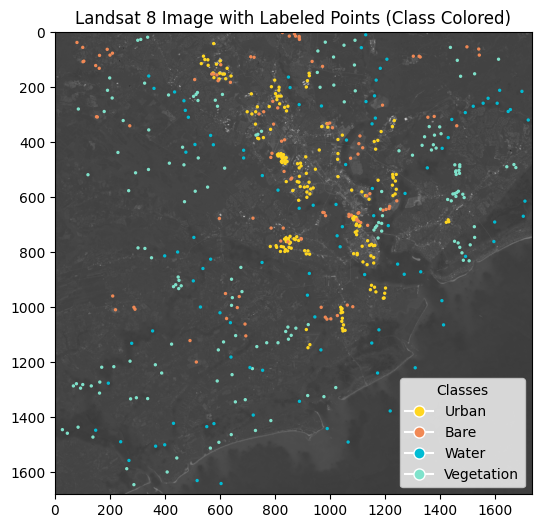

In [7]:
# ✅ Step 4: Define Class Mapping (Ensure all class labels are correct)
class_mapping = {
    "Urban": 0,
    "Bare": 1,
    "Water": 2,
    "Covered": 3
}

# Map class labels to numeric values
labels["Class_Num"] = labels["Class"].map(class_mapping)

# Check for unmapped values (NaN)
if labels["Class_Num"].isna().sum() > 0:
    print("Warning: Some labels were not mapped correctly!")
    print(labels[labels["Class_Num"].isna()])  # Show problematic rows

# Drop rows with NaN class values
labels = labels.dropna(subset=["Class_Num"])
labels["Class_Num"] = labels["Class_Num"].astype(int)  # Ensure integer type

# ✅ Step 5: Convert Label Coordinates to Pixel Coordinates
coords = [(x, y) for x, y in zip(labels.geometry.x, labels.geometry.y)]
pixels = [src.index(x, y) for x, y in coords]  # Convert to raster indices
rows, cols = zip(*pixels)  # Extract row and column values

# ✅ Step 6: Define Class Colors
class_colors = {
    0: "#ffd620",      # Urban
    1: "#f18955",     # Bare
    2: "#00bcd4",    # Water
    3: "#7fe2cb"    # Vegetation
}

# Assign colors to each point based on class
colors = [class_colors.get(c, "gray") for c in labels["Class_Num"]]

# ✅ Step 7: Plot the Landsat Image and Labeled Points
plt.figure(figsize=(8, 6))

# Display the first band of the Landsat image
plt.imshow(image[0], cmap="gray", extent=[0, image.shape[2], image.shape[1], 0])  # Flip y-axis

# Scatter plot with class-specific colors
plt.scatter(cols, rows, c=colors, s=2, alpha=1)

# ✅ Step 8: Add a Legend
legend_labels = ["Urban", "Bare", "Water", "Vegetation"]
legend_colors = [mcolors.to_rgba(class_colors[i]) for i in range(4)]
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=legend_colors[i], markersize=8) 
                    for i in range(4)], labels=legend_labels, title="Classes")

plt.title("Landsat 8 Image with Labeled Points (Class Colored)")
plt.show()




In [8]:
import numpy as np
import pandas as pd
import rasterio
import scipy.ndimage as ndimage

# ✅ Extract pixel values at labeled point locations
with rasterio.open(file_path) as src:
    labels["Pixel_Values"] = [list(src.sample([(x, y)]))[0] for x, y in zip(labels.geometry.x, labels.geometry.y)]

# ✅ Convert pixel values into a structured DataFrame
df = labels.drop(columns=["geometry"]).copy()
df[["Band_1", "Band_2", "Band_3", "Band_4", "Band_5", "Band_6", "Band_7"]] = pd.DataFrame(df["Pixel_Values"].tolist(), index=df.index)
df.drop(columns=["Pixel_Values"], inplace=True)

df.head()


,Class,Class_Num,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7
0,Urban,0,16192,17345,18638,19995,21988,20936,15751
1,Covered,3,8118,8209,8816,8556,16200,12841,10236
2,Urban,0,11689,12060,13111,13282,13390,14096,14073
3,Urban,0,9973,10171,10639,10937,13199,13601,12502
4,Urban,0,9706,9947,10855,10902,15330,14354,12654


In [9]:
print("Labels CRS:", labels.crs)

Labels CRS: EPSG:32617


In [10]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

dem_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\dem_slope_norm.tif"
out_dem_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\dem_reprojected.tif"

# 1. Open the original DEM
with rasterio.open(dem_path) as src:
    # 2. Define the target CRS (the same as your labels)
    dst_crs = labels.crs  # e.g., "EPSG:32617"

    # 3. Calculate the transform and dimensions for the new DEM
    transform, width, height = calculate_default_transform(
        src.crs,          # Current DEM CRS
        dst_crs,          # Target CRS (label's CRS)
        src.width,
        src.height,
        *src.bounds
    )
    
    # 4. Update metadata for the new DEM
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })
    
    # 5. Create and write the reprojected DEM
    with rasterio.open(out_dem_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

print("DEM reprojected to label's CRS:", labels.crs)
print("New DEM saved as:", out_dem_path)


DEM reprojected to label's CRS: EPSG:32617
New DEM saved as: D:\Course_25Spring\DEEPL\HW2\Final_works\dem_reprojected.tif


In [11]:
import numpy as np
import rasterio
import scipy.ndimage as ndimage
from rasterio.transform import rowcol

reprojected_dem_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\dem_reprojected.tif"

# 1) Load DEM (Elevation)
with rasterio.open(reprojected_dem_path) as dem_src:
    elevation_array = dem_src.read(1)  # Band 1 = Elevation
    transform_dem = dem_src.transform

# Extract Elevation at label points
df["Elevation"] = [
    elevation_array[rowcol(transform_dem, x, y)]
    for x, y in zip(labels.geometry.x, labels.geometry.y)
]

# 2) Compute Slope via Gradient
slope = np.gradient(elevation_array)  # slope is a tuple (dy, dx)
slope_magnitude = np.sqrt(slope[0]**2 + slope[1]**2)

df["Slope"] = [
    slope_magnitude[rowcol(transform_dem, x, y)]
    for x, y in zip(labels.geometry.x, labels.geometry.y)
]

# 3) Compute Spectral Indices
df["NDVI"] = (df["Band_5"] - df["Band_4"]) / (df["Band_5"] + df["Band_4"] + 1e-10)
df["NDBI"] = (df["Band_6"] - df["Band_5"]) / (df["Band_6"] + df["Band_5"] + 1e-10)
df["MNDWI"] = (df["Band_3"] - df["Band_6"]) / (df["Band_3"] + df["Band_6"] + 1e-10)

# 4) Normalize All Image Bands (Scale 0-1)
features = [
    "Band_1", "Band_2", "Band_3", "Band_4", "Band_5", "Band_6", "Band_7",
    "Elevation", "Slope", "NDVI", "NDBI", "MNDWI"
]
df[features] = (df[features] - df[features].min()) / (df[features].max() - df[features].min())

# 5) Apply Kernel Filters (Edge Detection & Smoothing)
#    Load the same Landsat band used for filtering
with rasterio.open(file_path) as src:
    img = src.read(1)  # e.g., Band 1 from Landsat
    transform = src.transform

# **Compute the entire filter arrays first** (2D) ...
sobel_img = ndimage.sobel(img)
smooth_img = ndimage.gaussian_filter(img, sigma=1)

# ... then extract pixel values at label points
df["Edge_Detection"] = [
    sobel_img[rowcol(transform, x, y)]
    for x, y in zip(labels.geometry.x, labels.geometry.y)
]

df["Smoothing"] = [
    smooth_img[rowcol(transform, x, y)]
    for x, y in zip(labels.geometry.x, labels.geometry.y)
]

# 6) Print first rows to check output
print(df.head())




     Class  Class_Num    Band_1    Band_2    Band_3    Band_4    Band_5  \
0    Urban          0  0.422111  0.426026  0.433468  0.460890  0.518003   
1  Covered          3  0.048782  0.032877  0.046913  0.038241  0.316457   
2    Urban          0  0.213899  0.198597  0.215947  0.212858  0.218609   
3    Urban          0  0.134554  0.117308  0.118659  0.126215  0.211958   
4    Urban          0  0.122208  0.107668  0.127160  0.124921  0.286162   

     Band_6    Band_7  Elevation     Slope      NDVI      NDBI     MNDWI  \
0  0.608491  0.517546   0.786885  0.117444  0.010201  0.342285  0.396391   
1  0.245209  0.176819   0.754098  0.052523  0.066662  0.487833  0.704859   
2  0.301530  0.413876   0.762295  0.133907  0.000818  0.005809  0.588737   
3  0.279316  0.316817   0.762295  0.262613  0.020194  0.003374  0.640596   
4  0.313109  0.326208   0.770492  0.111417  0.036417  0.495558  0.610668   

   Edge_Detection  Smoothing  
0           59597      15611  
1              76       8130  

In [68]:
df.shape[0]

569

In [12]:
from sklearn.model_selection import train_test_split

# Define your feature set and target
features = [
    "Band_1", "Band_2", "Band_3", "Band_4", "Band_5", "Band_6", "Band_7",
    "Elevation", "Slope", "NDVI", "NDBI", "MNDWI",
    "Edge_Detection", "Smoothing"
]
X = df[features]
y = df["Class_Num"]  # Must be integer

# 70% training, 30% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model1 = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training set
model1.fit(X_train, y_train)

importances = model1.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature ranking:")
for i in range(len(features)):
    print(f"{i+1}. {features[indices[i]]} ({importances[indices[i]]:.4f})")


Feature ranking:
1. Smoothing (0.1289)
2. Band_1 (0.1159)
3. Band_4 (0.0940)
4. Band_6 (0.0884)
5. Band_2 (0.0881)
6. Band_7 (0.0875)
7. Band_5 (0.0870)
8. MNDWI (0.0734)
9. NDVI (0.0504)
10. Band_3 (0.0489)
11. NDBI (0.0477)
12. Slope (0.0342)
13. Elevation (0.0291)
14. Edge_Detection (0.0265)


### Most Influential Features in the Classification Model:

**Smoothing (0.1289):**

This feature is the most influential in the classification model. Smoothing likely plays a significant role in distinguishing areas with noise or variability, helping the model make cleaner distinctions between land cover types.

**Band_1 (0.1159):**

Band_1 (which likely represents a certain wavelength of light) is highly important, showing that this band provides essential spectral information for classification, particularly for distinguishing land cover types.

**Band_4 (0.0940) and Band_6 (0.0884):**

These bands are also highly influential, suggesting that Band_4 (red) and Band_6 (SWIR), typical for vegetation and moisture detection, are key for identifying features like vegetation or water.

**Band_2 (0.0881) and Band_7 (0.0875):**

These bands (likely in the visible and infrared regions) also play a significant role. Band_2 (green) helps in vegetation detection, and Band_7 (SWIR) may be useful in differentiating between vegetation and urban areas.


### Less Influential Features:

**Edge_Detection (0.0265):**

This feature has the least importance, implying that edge detection does not contribute as much to the classification. While it can help in delineating boundaries, other spectral features seem to be more critical for classification.

**Slope (0.0342) and Elevation (0.0291):**

These features are also relatively less influential, indicating that topographic features like slope and elevation play a smaller role in this specific classification task, perhaps due to the urban and vegetation-based nature of the labels.

Next we will select the most influential factors and eliminate some others, and retrain the model

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on the validation set
y_pred1 = model1.predict(X_val)

# Compute accuracy
accuracy = accuracy_score(y_val, y_pred1)
print("Validation Accuracy:", accuracy)

# Print confusion matrix
cm = confusion_matrix(y_val, y_pred1)
print("Confusion Matrix:\n", cm)

# Classification report
report = classification_report(y_val, y_pred1, target_names=["Urban", "Bare", "Water", "Vegetation"])
print("Classification Report:\n", report)


Validation Accuracy: 0.8654970760233918
Confusion Matrix:
 [[58  2  0  5]
 [ 7 26  0  2]
 [ 0  0 25  3]
 [ 0  2  2 39]]
Classification Report:
               precision    recall  f1-score   support

       Urban       0.89      0.89      0.89        65
        Bare       0.87      0.74      0.80        35
       Water       0.93      0.89      0.91        28
  Vegetation       0.80      0.91      0.85        43

    accuracy                           0.87       171
   macro avg       0.87      0.86      0.86       171
weighted avg       0.87      0.87      0.86       171



In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define your feature set and target
features2 = [
    "Smoothing", "Band_1", "Band_4", "Band_6", "Band_2", "Elevation", "Slope",
    "Band_7", "Band_5", "MNDWI", "NDVI", "Band_3"
]

X = df[features2]
y = df["Class_Num"]

# Define Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Apply 5-fold cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Compute mean and standard deviation of accuracy
mean_accuracy = cv_scores.mean()
std_accuracy = cv_scores.std()

print(f"Cross-Validation Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")


Cross-Validation Accuracy: 0.8206 ± 0.0398


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],  
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="accuracy")
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Train final model with optimal parameters
model3 = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model3.fit(X_train, y_train)

# Predict on validation set
y_pred3 = model3.predict(X_val)

# Compute accuracy
accuracy = accuracy_score(y_val, y_pred3)
print(f"Validation Accuracy: {accuracy:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred3)
print("Confusion Matrix:\n", cm)

# Classification report
class_labels = ["Urban", "Bare", "Water", "Vegetation"]
report = classification_report(y_val, y_pred3, target_names=class_labels)
print("Classification Report:\n", report)


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Validation Accuracy: 0.8538
Confusion Matrix:
 [[57  3  0  5]
 [ 7 24  0  4]
 [ 0  0 25  3]
 [ 0  1  2 40]]
Classification Report:
               precision    recall  f1-score   support

       Urban       0.89      0.88      0.88        65
        Bare       0.86      0.69      0.76        35
       Water       0.93      0.89      0.91        28
  Vegetation       0.77      0.93      0.84        43

    accuracy                           0.85       171
   macro avg       0.86      0.85      0.85       171
weighted avg       0.86      0.85      0.85       171



Comparing the 3 models, the first is the initial one containing all the features, the 2nd is selecting the few most important ones, the 3rd is searching for the most optical ones, and their accuracy decreased, so eventually the first one including all the features are selected.

In [18]:
import rasterio
import numpy as np
import pandas as pd
from scipy import ndimage
from sklearn.preprocessing import MinMaxScaler

# Paths
DEM_PATH = "dem_reprojected.tif"
TIF_PATH = "Landsat_Charleston2.tif"
CLASSIFIED_TIF_PATH = "classified_result.tif"

# Open DEM and TIF
with rasterio.open(DEM_PATH) as dem_src:
    elevation_array = dem_src.read(1)

with rasterio.open(TIF_PATH) as tif_src:
    img_bands = tif_src.read()
    meta = tif_src.meta
    height, width = meta['height'], meta['width']

# Calculate Slope
dy, dx = np.gradient(elevation_array)
slope_magnitude = np.sqrt(dx**2 + dy**2)

# NDVI, NDBI, MNDWI calculations
ndvi = (img_bands[4] - img_bands[3]) / (img_bands[4] + img_bands[3] + 1e-10)
ndbi = (img_bands[5] - img_bands[4]) / (img_bands[5] + img_bands[4] + 1e-10)
mndwi = (img_bands[2] - img_bands[5]) / (img_bands[2] + img_bands[5] + 1e-10)

# Edge Detection & Smoothing
sobel_img = ndimage.sobel(img_bands[0])
smooth_img = ndimage.gaussian_filter(img_bands[0], sigma=1)

# Construct Feature Matrix
feature_matrix = []
for i in range(height):
    for j in range(width):
        pixel_values = img_bands[:, i, j]
        elevation = elevation_array[i, j]
        slope_val = slope_magnitude[i, j]
        features = list(pixel_values) + [elevation, slope_val, ndvi[i,j], ndbi[i,j], mndwi[i,j], sobel_img[i,j], smooth_img[i,j]]
        feature_matrix.append(features)

# Feature Column Names
feature_columns = [f"Band_{i+1}" for i in range(img_bands.shape[0])] + ["Elevation", "Slope", "NDVI", "NDBI", "MNDWI", "Edge_Detection", "Smoothing"]
df_features = pd.DataFrame(feature_matrix, columns=feature_columns)

# Normalize features
scaler = MinMaxScaler()
df_features_scaled = scaler.fit_transform(df_features)

# Predict using trained model
predictions = model1.predict(df_features_scaled)

# Reshape predictions
classified_image = predictions.reshape((height, width)).astype(np.uint8)

# Save classified GeoTIFF
meta.update(count=1, dtype='uint8')
output_path = 'classified_Landsat8_map.tif'

with rasterio.open(output_path, 'w', **meta) as dst:
    dst.write(classified_image, 1)

print(f"Classified GeoTIFF saved at: {output_path}")

Classified GeoTIFF saved at: classified_Landsat8_map.tif


Downloaded the ESA World Cover Map for our area of interest, which is Charleston, the resolution is set to be 30 meters.

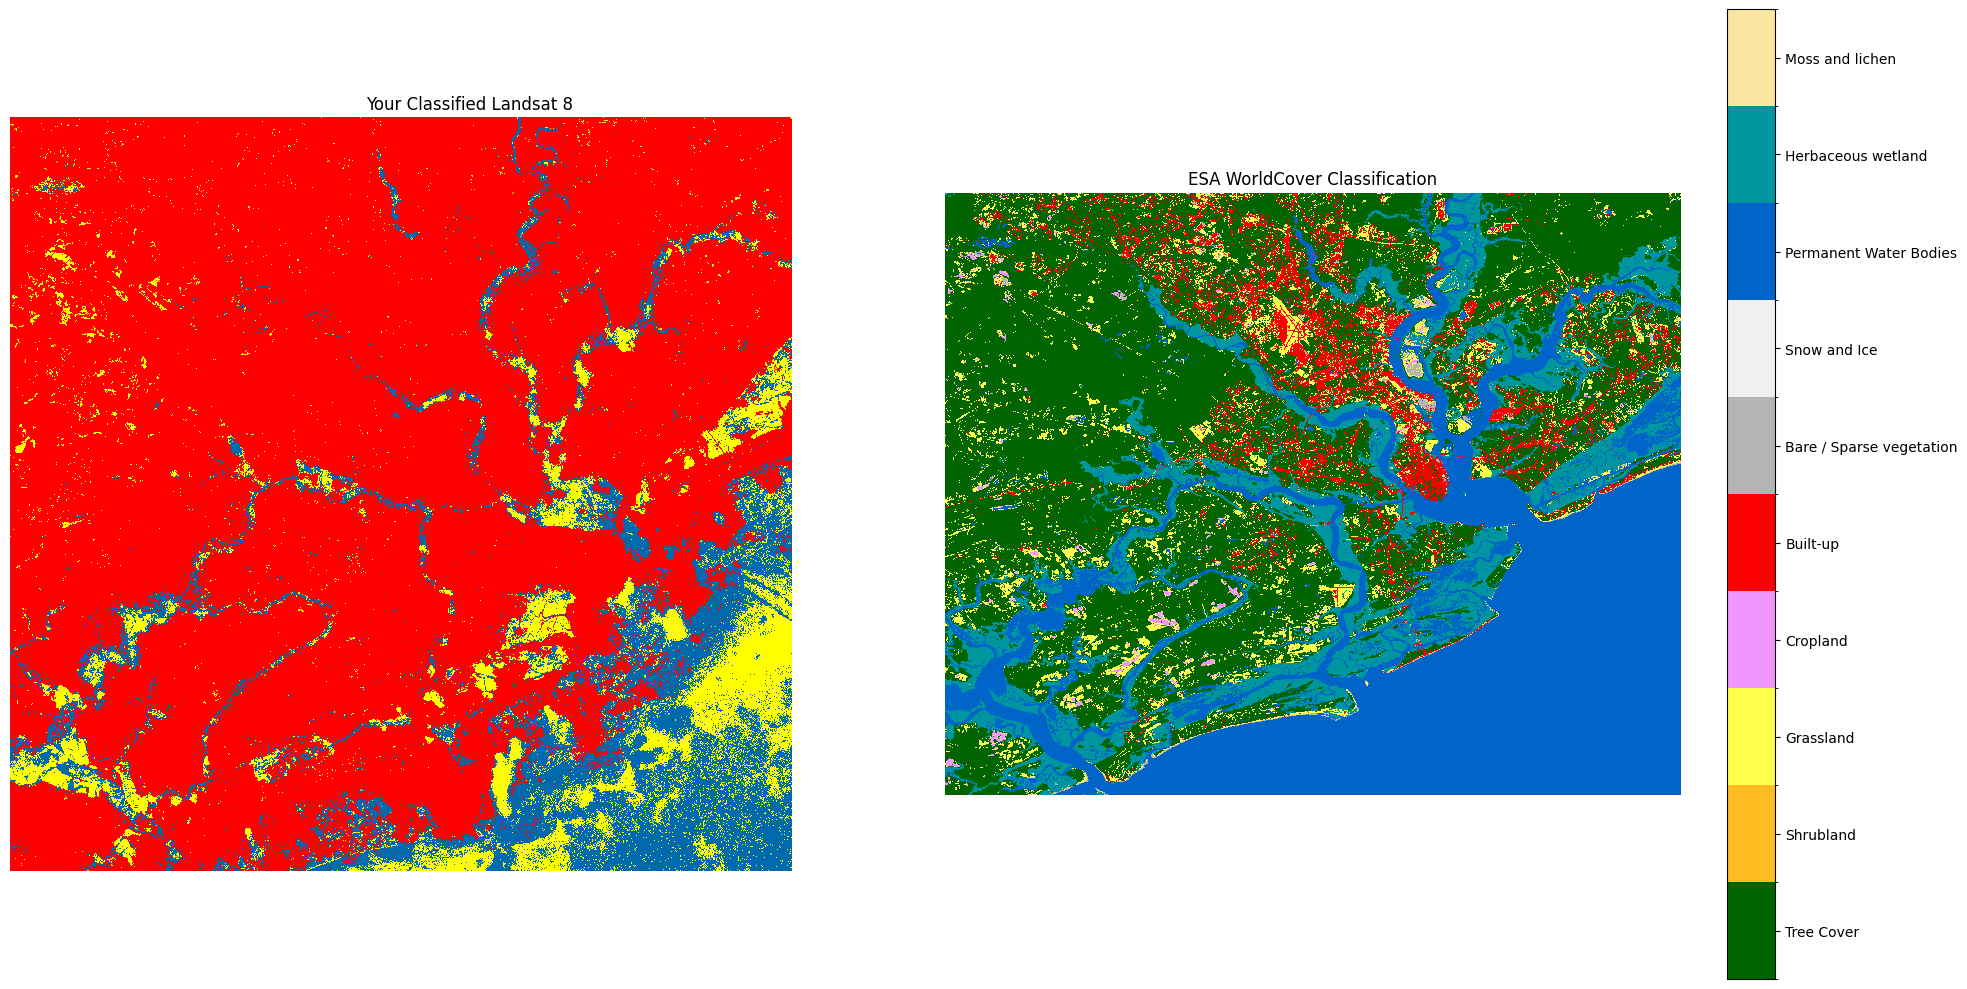

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as colors

# Paths
classified_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\classified_Landsat8_map.tif"
esa_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\ESA_WorldCover_Charleston_30m.tif"

# Load images
with rasterio.open(classified_path) as src:
    classified_img = src.read(1)
with rasterio.open(esa_path) as esa_src:
    esa_img = esa_src.read(1)

# Define classification labels and colors for Landsat (classes 0, 1, 2, 3)
landsat_class_labels = {
    0: 'Urban',
    1: 'Bare Land',
    2: 'Water',
    3: 'Vegetation'
}
landsat_colors = ['red', 'yellow', '#006aaf', 'green']
landsat_cmap = ListedColormap(landsat_colors)
landsat_bounds = [0, 1, 2, 3, 4]
landsat_norm = BoundaryNorm(landsat_bounds, len(landsat_colors))

# Define ESA class labels and colors (classes 10, 20, 30, …, 100)
esa_class_labels = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse vegetation",
    70: "Snow and Ice",
    80: "Permanent Water Bodies",
    90: "Herbaceous wetland",
    100: "Moss and lichen"
}
esa_colors = [
    "#006400", "#ffbb22", "#ffff4c", "#f096ff", "#fa0000",
    "#b4b4b4", "#f0f0f0", "#0064c8", "#0096a0", "#fae6a0"
]
esa_cmap = ListedColormap(esa_colors)
# Set boundaries so that each class (centered on 10, 20, …, 100) is represented correctly.
esa_bounds = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
esa_norm = BoundaryNorm(esa_bounds, len(esa_colors))

# Plotting: create subplots with shared axes and equal aspect ratios
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

# Landsat image plot
ax[0].imshow(classified_img, cmap=landsat_cmap, norm=landsat_norm, interpolation='none')
ax[0].set_title('Your Classified Landsat 8')
ax[0].axis('off')
ax[0].set_aspect('equal')

# ESA WorldCover image plot
im = ax[1].imshow(esa_img, cmap=esa_cmap, norm=esa_norm, interpolation='none')
cbar = plt.colorbar(im, ax=ax[1], ticks=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
cbar.ax.set_yticklabels([esa_class_labels[k] for k in sorted(esa_class_labels.keys())])
ax[1].set_title('ESA WorldCover Classification')
ax[1].axis('off')
ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()



Compared to the ESA WorldCover classification, the water category is most accurately predicted—capturing nearly every canal, small lake, and water body. However, the model struggles to distinguish between bare land and vegetation. A close examination of the original TIFF reveals that the bare areas and the darker portions of the water are very similar, while vegetation is significantly under-predicted.

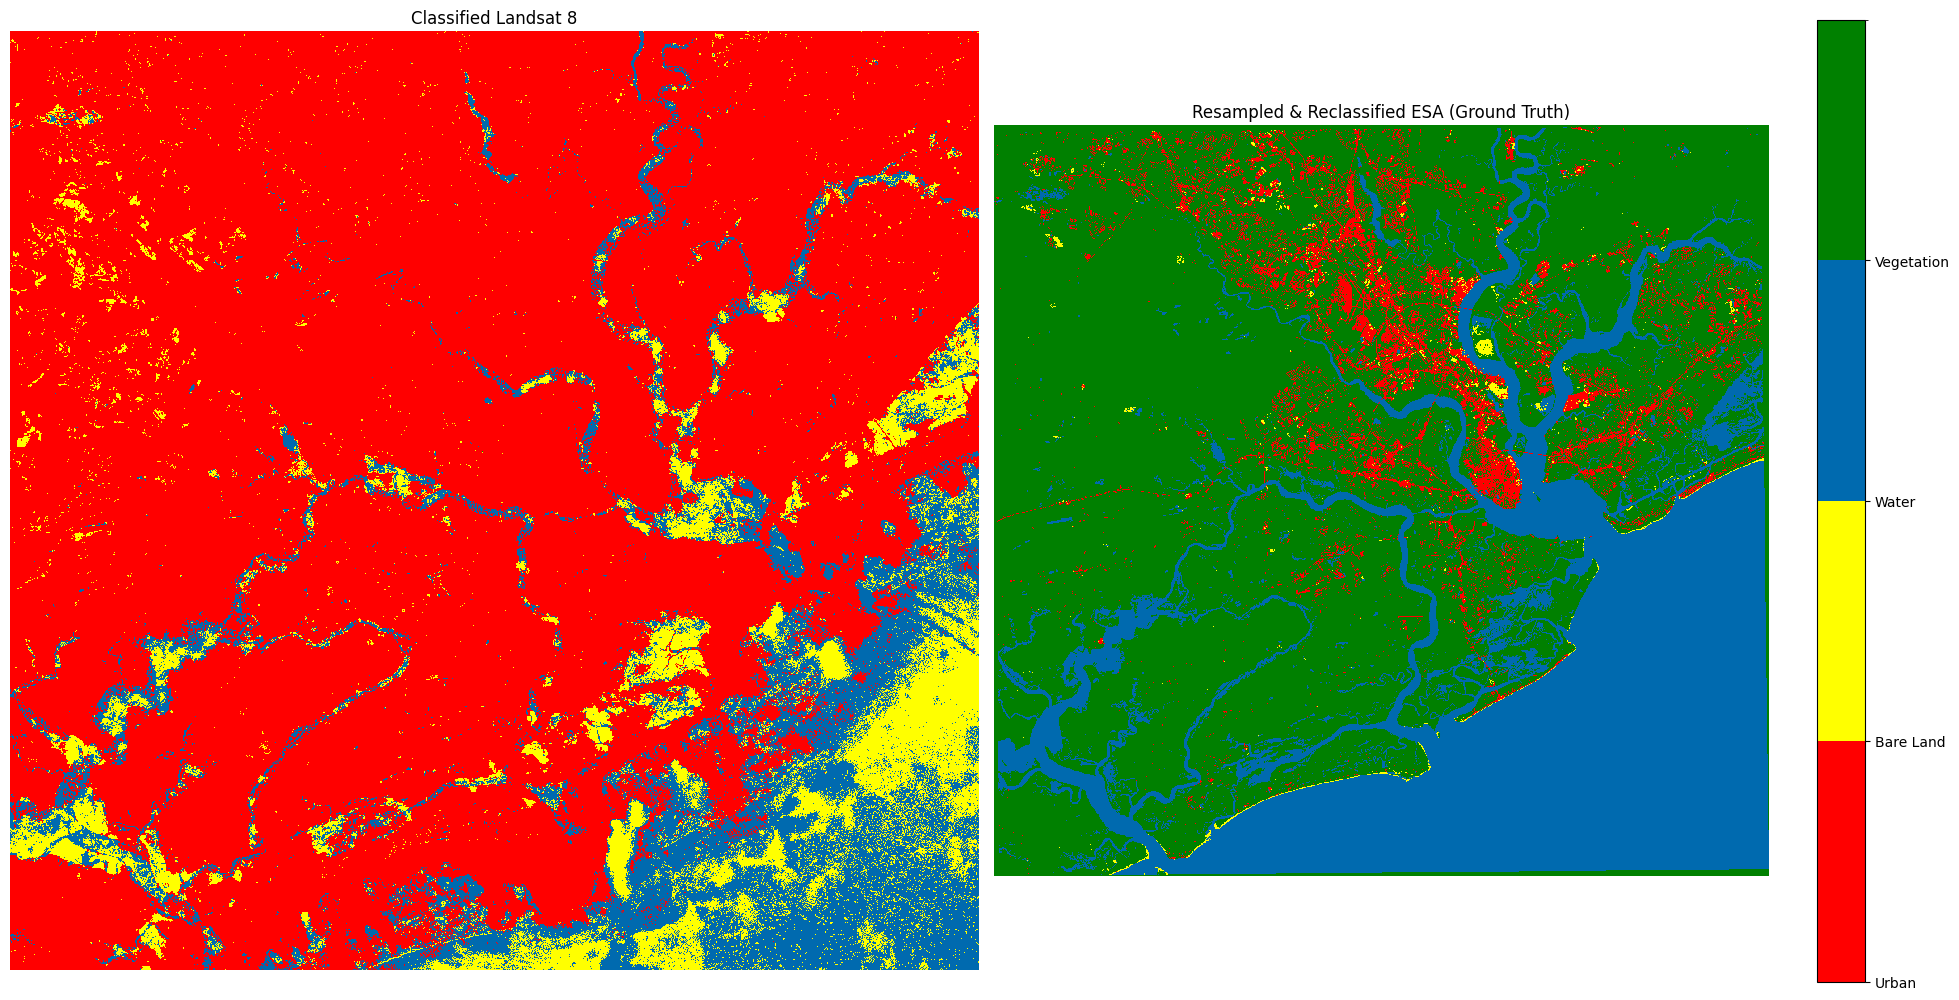

Exported classified image to D:\Course_25Spring\DEEPL\HW2\Final_works\export_classified_Landsat8_map.tif
Exported classification metrics to D:\Course_25Spring\DEEPL\HW2\Final_works\classification_metrics.csv


In [31]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Paths
classified_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\classified_Landsat8_map.tif"
esa_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\ESA_WorldCover_Charleston_30m.tif"
export_classified_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\export_classified_Landsat8_map.tif"
metrics_csv_path = r"D:\Course_25Spring\DEEPL\HW2\Final_works\classification_metrics.csv"

# ---------------------- Load Landsat Classified Image ---------------------- #
with rasterio.open(classified_path) as landsat_src:
    classified_img = landsat_src.read(1)
    landsat_meta = landsat_src.meta.copy()
    landsat_transform = landsat_src.transform
    landsat_crs = landsat_src.crs
    landsat_width = landsat_src.width
    landsat_height = landsat_src.height

# ---------------------- Load ESA Image ---------------------- #
with rasterio.open(esa_path) as esa_src:
    esa_img = esa_src.read(1)
    esa_transform = esa_src.transform
    esa_crs = esa_src.crs

# ---------------------- Resample and Crop ESA Image ---------------------- #
# Create an empty array matching Landsat geometry
esa_resampled = np.empty((landsat_height, landsat_width), dtype=esa_img.dtype)

# Reproject (with nearest neighbor resampling, ideal for categorical data)
reproject(
    source=esa_img,
    destination=esa_resampled,
    src_transform=esa_transform,
    src_crs=esa_crs,
    dst_transform=landsat_transform,
    dst_crs=landsat_crs,
    resampling=Resampling.nearest
)

# ---------------------- Reclassify ESA Image ---------------------- #
# Map: ESA 50 -> 0 (Urban), ESA 60 -> 1 (Bare Land), ESA 80 -> 2 (Water), else -> 3 (Vegetation)
esa_reclass = np.select(
    [esa_resampled == 50, esa_resampled == 60, esa_resampled == 80],
    [0, 1, 2],
    default=3
)

# ---------------------- Define Color Maps and Norms ---------------------- #
# For Landsat and reclassified ESA, we use the same colors:
landsat_class_labels = {0: 'Urban', 1: 'Bare Land', 2: 'Water', 3: 'Vegetation'}
landsat_colors = ['red', 'yellow', '#006aaf', 'green']
landsat_cmap = ListedColormap(landsat_colors)
landsat_bounds = [0, 1, 2, 3, 4]
landsat_norm = BoundaryNorm(landsat_bounds, len(landsat_colors))

# For ESA reclassified image (same as Landsat)
esa_class_labels = landsat_class_labels.copy()
esa_cmap = ListedColormap(landsat_colors)
esa_bounds = landsat_bounds
esa_norm = BoundaryNorm(esa_bounds, len(landsat_colors))

# ---------------------- Plot Comparison ---------------------- #
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

# Landsat Classified Image
ax[0].imshow(classified_img, cmap=landsat_cmap, norm=landsat_norm, interpolation='none')
ax[0].set_title('Classified Landsat 8')
ax[0].axis('off')
ax[0].set_aspect('equal')

# Resampled & Reclassified ESA Image (Ground Truth)
im = ax[1].imshow(esa_reclass, cmap=esa_cmap, norm=esa_norm, interpolation='none')
cbar = plt.colorbar(im, ax=ax[1], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels([esa_class_labels[k] for k in sorted(esa_class_labels.keys())])
ax[1].set_title('Resampled & Reclassified ESA (Ground Truth)')
ax[1].axis('off')
ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# ---------------------- Export Classified Image as GeoTIFF ---------------------- #
landsat_meta.update(dtype='uint8', count=1)
with rasterio.open(export_classified_path, 'w', **landsat_meta) as dst:
    dst.write(classified_img.astype(np.uint8), 1)
print(f"Exported classified image to {export_classified_path}")

# ---------------------- Compute and Export Metrics ---------------------- #
# Flatten arrays for per-pixel comparison
landsat_flat = classified_img.flatten()
esa_reclass_flat = esa_reclass.flatten()

# Calculate confusion matrix, overall accuracy, and detailed classification report
cm = confusion_matrix(esa_reclass_flat, landsat_flat, labels=[0, 1, 2, 3])
accuracy = accuracy_score(esa_reclass_flat, landsat_flat)
report = classification_report(
    esa_reclass_flat, landsat_flat,
    target_names=[landsat_class_labels[i] for i in [0, 1, 2, 3]],
    output_dict=True
)

# Convert metrics to DataFrames
cm_df = pd.DataFrame(
    cm,
    index=["True_" + landsat_class_labels[i] for i in [0, 1, 2, 3]],
    columns=["Pred_" + landsat_class_labels[i] for i in [0, 1, 2, 3]]
)
report_df = pd.DataFrame(report).transpose()

# Export metrics to a CSV file
with open(metrics_csv_path, 'w') as f:
    f.write("Confusion Matrix\n")
    cm_df.to_csv(f)
    f.write("\nClassification Report\n")
    report_df.to_csv(f)
print(f"Exported classification metrics to {metrics_csv_path}")


**What limitations did you run into when completing this assignment? What might you do differently if you repeated it, or what might you change if you had more time and/or resources?**

One of the main limitations I faced was the relatively small amount of labeled data, particularly for vegetation and bare land classes that share very similar spectral signatures. This made it difficult for the model to learn fine‐grained differences between those classes. If I were to do this again or had more time, I would label more data points—and even polygons—to better capture the variability within each class. This expanded ground truth would likely improve the model’s ability to distinguish subtle differences, especially for classes that appear visually or spectrally alike.

**What was the impact of feature engineering? Which layers most contributed to the model? Did you expect this? Why or why not?**

Feature engineering appears to have played a key role in improving classification accuracy by giving the model additional perspectives beyond raw spectral values. Based on the feature ranking, smoothing came out on top, followed by several individual spectral bands (Band 1, Band 4, Band 6, Band 2, Band 7, Band 5). Interestingly, the water‐related index (MNDWI) ranked higher than the vegetation‐related NDVI, and terrain‐based features like slope and elevation were closer to the bottom.

Smoothing ranking first might be surprising, but it suggests that local texture (smoothed pixel values) helped the model separate classes that are otherwise spectrally similar.


**Did you find it difficult to create the training data by hand? Did you notice any issues with class imbalance? If so, how might you resolve this in the future (hint: consider a different sampling technique).**

Creating the training data by hand was indeed time‐consuming and somewhat challenging, especially for classes that look similar on the ground or in imagery (e.g., bare land vs. darker water areas). In addition, I noticed some degree of class imbalance—certain land‐cover types were more frequently sampled than others. This imbalance can bias the model to favor majority classes. I would try using label polygons rather than single points. This can capture more variability within each class in a single pass, potentially improving class balance. I would also iteratively label only the most “uncertain” or “difficult” samples, letting the model guide which pixels need labeling

**Did your model perform better on one class than another? Why? Can you think of a reason that this might be good or bad depending on the context?**

Water perform better than other classes, water bodies often have very characteristic reflectance patterns, especially when using indices like MNDWI. That makes them easier for the model to isolate from other classes. Urban surfaces can sometimes resemble bare land or even vegetation (e.g., if roofs are covered with vegetation or dust). If the training data for Urban were limited or not diverse enough, the model may fail to learn all the nuances of urban reflectance.